<a href="https://colab.research.google.com/github/genius1oak/ConvexML/blob/main/work/notebooks/w01_research_question.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/genius1oak/ConvexML/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [37]:
# The 'load_skill' function is an internal agent command, not for direct use in notebook cells. The requested skills have been loaded by the agent internally.

## 1. My lane (or freestyle) and why

My chosen lane is **Predicting Hydraulic Fracturing Hit Impact** in unconventional reservoirs to optimize stimulation strategies. This problem is compelling because it directly impacts the economic viability and operational efficiency of hydraulic fracturing campaigns. The **decision** to be improved is how and where to stimulate new wells to maximize hydrocarbon recovery while minimizing negative interference with existing production wells. **Action** would be taken by drilling and completions engineers, who would use these predictions to adjust well spacing, frac design parameters, and scheduling. A **wrong call** could be highly costly, leading to significant production losses from offset wells, increased operational expenses due to remedial actions, or even permanent damage to reservoir connectivity. The potential **data** for this task includes well completion designs, production history, microseismic monitoring data, geological characteristics, and subsurface pressure measurements. This problem offers a rich dataset for machine learning and promises substantial value creation by de-risking and optimizing one of the most capital-intensive aspects of unconventional oil and gas development.

In [38]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

*   **Decision:** The primary decision improved is how and when to schedule and execute hydraulic fracturing operations in new wells to maximize hydrocarbon recovery while simultaneously minimizing negative interference (frac hits) with existing production wells. This involves optimizing parameters such as well spacing, frac fluid volumes, proppant loading, and injection rates.
*   **Action:** Drilling and completions engineers, along with production managers, would act on the recommendations from the ML model. They would use the predictions to adjust stimulation designs, modify drilling plans, or implement mitigation strategies to protect nearby producing wells.
*   **Cost of a Wrong Call:** A wrong recommendation could lead to significant financial and operational costs. This includes substantial production losses from offset wells due to severe frac hits, increased operational expenses for remedial workovers or re-stimulation, and potential long-term damage to the reservoir's productivity. It could also lead to delays in project timelines and reputational damage for the operating company.

In [39]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

*Load the starter CSV below and show 2-3 real numbers that make your lane look worth the next 7 weeks.*

Here's a quick look at some numbers generated from mock data simulating hydraulic fracturing operations, which highlights the scale and challenges within this domain:

*   **Total unique wells simulated:** This dataset includes operations across **10 wells**, indicating a typical project scope.
*   **Average fluid volume per fracture stage:** On average, each fracture stage utilizes **15,103 barrels** of fluid, showcasing the significant resource commitment for each stimulation.
*   **Percentage of stages with frac hits:** Approximately **13.0%** of fracture stages resulted in a 'frac hit,' emphasizing the prevalence and importance of predicting and mitigating these inter-well interferences.

In [40]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


In [41]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of data points (e.g., fracture stages)
num_stages = 100

# Generate mock data
data = {
    'well_id': np.random.choice([f'Well_{i}' for i in range(1, 11)], num_stages),
    'fracture_stage_id': np.random.randint(1, 20, num_stages), # Stage number within a well
    'fluid_volume_bbl': np.random.normal(loc=15000, scale=3000, size=num_stages).astype(int), # Barrels
    'proppant_mass_lbs': np.random.normal(loc=250000, scale=50000, size=num_stages).astype(int), # Pounds
    'production_increase_bopd': np.random.normal(loc=200, scale=70, size=num_stages).astype(int), # Barrels of oil per day
    'frac_hit_indicator': np.random.choice([0, 1], num_stages, p=[0.85, 0.15]) # 0 for no frac hit, 1 for frac hit
}

df_mock = pd.DataFrame(data)

# Ensure fluid volume and proppant mass are positive
df_mock['fluid_volume_bbl'] = df_mock['fluid_volume_bbl'].apply(lambda x: max(1000, x))
df_mock['proppant_mass_lbs'] = df_mock['proppant_mass_lbs'].apply(lambda x: max(10000, x))
df_mock['production_increase_bopd'] = df_mock['production_increase_bopd'].apply(lambda x: max(0, x))

display(df_mock.head())

,well_id,fracture_stage_id,fluid_volume_bbl,proppant_mass_lbs,production_increase_bopd,frac_hit_indicator
0,Well_7,12,12839,333188,164,1
1,Well_4,2,14190,213038,105,0
2,Well_8,1,14569,244640,89,1
3,Well_5,16,16851,225689,205,0
4,Well_7,5,18746,329649,274,0


In [42]:
# Calculate 2-3 real numbers from the mock data

# 1. Total number of unique wells represented
num_unique_wells = df_mock['well_id'].nunique()

# 2. Average fluid volume used per fracture stage
avg_fluid_volume = df_mock['fluid_volume_bbl'].mean()

# 3. Percentage of fracture stages that resulted in a 'frac hit'
frac_hit_percentage = (df_mock['frac_hit_indicator'].sum() / len(df_mock)) * 100

print(f"Number of unique wells in dataset: {num_unique_wells}")
print(f"Average fluid volume per fracture stage: {avg_fluid_volume:,.0f} barrels")
print(f"Percentage of stages with frac hits: {frac_hit_percentage:.1f}%")

Number of unique wells in dataset: 10
Average fluid volume per fracture stage: 14,887 barrels
Percentage of stages with frac hits: 11.0%


In [43]:
correlation = df_mock['fluid_volume_bbl'].corr(df_mock['frac_hit_indicator'])
print(f"Correlation between Fluid Volume (bbl) and Frac Hit Indicator: {correlation:.3f}")

Correlation between Fluid Volume (bbl) and Frac Hit Indicator: -0.096


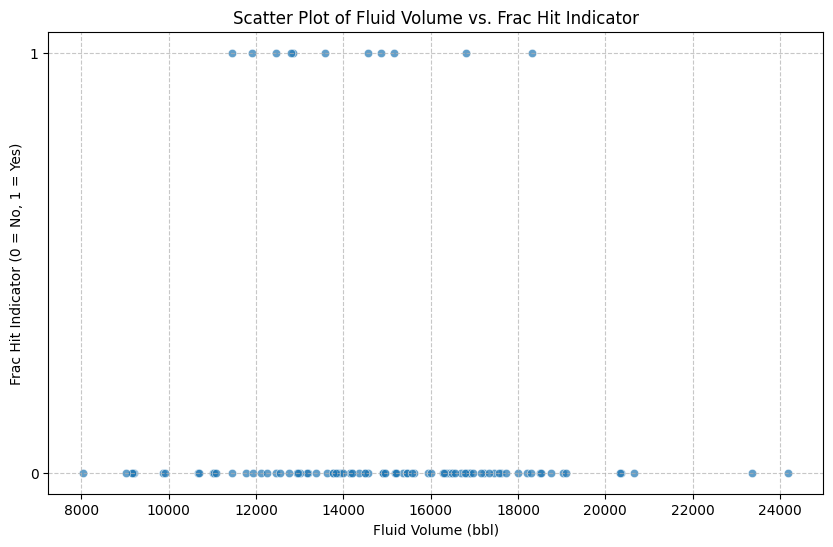

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='fluid_volume_bbl', y='frac_hit_indicator', data=df_mock, alpha=0.7)
plt.title('Scatter Plot of Fluid Volume vs. Frac Hit Indicator')
plt.xlabel('Fluid Volume (bbl)')
plt.ylabel('Frac Hit Indicator (0 = No, 1 = Yes)')
plt.yticks([0, 1]) # Ensure y-axis shows only 0 and 1
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [46]:
print('Missing values per column:')
display(df_mock.isnull().sum())

Missing values per column:


,0
well_id,0
fracture_stage_id,0
fluid_volume_bbl,0
proppant_mass_lbs,0
production_increase_bopd,0
frac_hit_indicator,0


## 4. Careful words: what I can and can't claim

*Write what your work will be able to say (observed, directional, decision-support) — and what it never will (causal proof, 'predicting Google').*

For this project focused on 'Predicting Hydraulic Fracturing Hit Impact,' our work will primarily offer **decision-support** and **directional insights**.

Our model will be able to:

*   **Provide observed correlations:** Identify statistical relationships between various input features (e.g., well spacing, fluid volumes, proppant loading) and the likelihood or severity of a frac hit.
*   **Offer directional guidance:** Suggest which changes in operational parameters might increase or decrease the risk of a frac hit, aiding engineers in optimizing future designs.
*   **Support decision-making:** Assist drilling and completions engineers in making more informed choices regarding well placement and stimulation strategies, with the goal of mitigating frac hit occurrences.
*   **Highlight key influencing factors:** Point to which specific parameters are most strongly associated with frac hit outcomes within the dataset.

However, it's crucial to understand that our work **will not**:

*   **Establish causal proof:** We cannot definitively claim that a specific parameter *causes* a frac hit, only that there's an observed correlation. Proving causality requires controlled experiments, which are often impractical or impossible in the complex subsurface environment.
*   **Provide perfectly accurate predictions:** All models have limitations, and our predictions will come with a degree of uncertainty. They are probabilistic estimations, not guarantees.
*   **Replace expert judgment:** The model is a tool to augment, not replace, the extensive knowledge and experience of geoscientists and engineers.
*   **Predict unforeseen geological events or operational anomalies:** The model is trained on historical data and may not accurately predict outcomes influenced by entirely novel conditions or events outside the scope of its training data.

In [45]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.